In [39]:
import pandas as pd 
import numpy as np 

In [40]:
!pip install pandas


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
!pip install numpy


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
!pip install matplotlib


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
!pip install seaborn
!pip install sklearn
!pip install warnings


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [44]:
!pip install scikit-learn


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, accuracy_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [46]:
df = pd.read_csv("telecom_customer_churn_dataset.csv", sep=';',decimal=',')
df.head()

,CustomerID,Gender,Age,SeniorCitizen,Partner,Dependents,TenureMonths,PhoneService,InternetService,TechSupport,OnlineSecurity,StreamingTV,PaperlessBilling,ContractType,PaymentMethod,MonthlyCharges,TotalCharges,SatisfactionScore,Churn
0,CUST00001,Male,58,No,Yes,Yes,14,Yes,Fiber optic,Yes,Yes,No,Yes,Month-to-month,Credit card,22.50,307.19,10,Yes
1,CUST00002,Male,46,No,Yes,No,35,Yes,Fiber optic,No,No,No,No,Month-to-month,Bank transfer,100.94,3504.43,3,Yes
2,CUST00003,Female,56,No,Yes,Yes,33,Yes,NaN,Yes,No,Yes,Yes,One year,Bank transfer,100.71,3302.75,9,No
3,CUST00004,Male,23,No,Yes,Yes,29,Yes,DSL,No,Yes,No,No,Month-to-month,Mailed check,106.65,3063.80,6,Yes
4,CUST00005,Female,35,No,Yes,No,71,No,Fiber optic,Yes,Yes,No,No,Month-to-month,Credit card,41.96,2955.93,7,Yes


In [47]:
print(f'The dataset contains {df.shape[0]} rows and {df.shape[1]} columns.')

The dataset contains 500 rows and 19 columns.


In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         500 non-null    str    
 1   Gender             500 non-null    str    
 2   Age                500 non-null    int64  
 3   SeniorCitizen      500 non-null    str    
 4   Partner            500 non-null    str    
 5   Dependents         500 non-null    str    
 6   TenureMonths       500 non-null    int64  
 7   PhoneService       500 non-null    str    
 8   InternetService    321 non-null    str    
 9   TechSupport        500 non-null    str    
 10  OnlineSecurity     500 non-null    str    
 11  StreamingTV        500 non-null    str    
 12  PaperlessBilling   500 non-null    str    
 13  ContractType       500 non-null    str    
 14  PaymentMethod      500 non-null    str    
 15  MonthlyCharges     500 non-null    float64
 16  TotalCharges       500 non-null    fl

In [49]:
df.dtypes

CustomerID               str
Gender                   str
Age                    int64
SeniorCitizen            str
Partner                  str
Dependents               str
TenureMonths           int64
PhoneService             str
InternetService          str
TechSupport              str
OnlineSecurity           str
StreamingTV              str
PaperlessBilling         str
ContractType             str
PaymentMethod            str
MonthlyCharges       float64
TotalCharges         float64
SatisfactionScore      int64
Churn                    str
dtype: object

In [50]:
df.TotalCharges.values

array([ 307.19, 3504.43, 3302.75, 3063.8 , 2955.93,  808.95, 4318.73,
        126.28, 1625.43, 2545.6 ,  923.19, 2261.91,  498.91,  621.43,
        274.88, 1758.91,  593.07, 8649.85,  760.71, 5563.39, 2454.91,
       1197.7 , 1211.52,  826.34, 1465.93, 4189.73, 5978.59,   43.3 ,
       2257.17, 3098.69,  802.56,  236.69,  180.08, 1886.26,  361.83,
       2287.  , 4612.65, 5615.74, 2599.83, 4035.24, 1401.46, 1084.27,
       3027.09, 6826.98,  376.04, 3231.79, 3120.47, 3292.22, 2789.42,
       5432.83, 2302.24, 1301.33, 2869.46, 3937.04, 7480.8 , 1005.39,
       1864.88, 3930.52, 5275.82,   87.3 , 1274.6 , 4304.64, 4945.94,
        380.58, 5051.81, 1392.98, 1740.47, 1051.68,   35.59, 3310.99,
        574.12,  876.56, 4072.87,   -2.68, 3959.86, 1411.7 , 2636.41,
        297.05,  548.45,  830.47, 3849.37, 8076.96,  514.76, 2388.45,
       4035.06,  433.89, 4579.76, 4182.7 , 2212.78, 1266.65, 2774.62,
       5044.57, 5810.19, 6946.06,  411.25, 3584.24, 1828.29, 6463.87,
       2703.36, 2226

In [51]:
df['MonthlyCharges'] = df['MonthlyCharges'].replace(' ', np.nan)
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'])

df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [52]:
np.set_printoptions(suppress=True, precision=2)
df.MonthlyCharges.values
df.TotalCharges.values

array([ 307.19, 3504.43, 3302.75, 3063.8 , 2955.93,  808.95, 4318.73,
        126.28, 1625.43, 2545.6 ,  923.19, 2261.91,  498.91,  621.43,
        274.88, 1758.91,  593.07, 8649.85,  760.71, 5563.39, 2454.91,
       1197.7 , 1211.52,  826.34, 1465.93, 4189.73, 5978.59,   43.3 ,
       2257.17, 3098.69,  802.56,  236.69,  180.08, 1886.26,  361.83,
       2287.  , 4612.65, 5615.74, 2599.83, 4035.24, 1401.46, 1084.27,
       3027.09, 6826.98,  376.04, 3231.79, 3120.47, 3292.22, 2789.42,
       5432.83, 2302.24, 1301.33, 2869.46, 3937.04, 7480.8 , 1005.39,
       1864.88, 3930.52, 5275.82,   87.3 , 1274.6 , 4304.64, 4945.94,
        380.58, 5051.81, 1392.98, 1740.47, 1051.68,   35.59, 3310.99,
        574.12,  876.56, 4072.87,   -2.68, 3959.86, 1411.7 , 2636.41,
        297.05,  548.45,  830.47, 3849.37, 8076.96,  514.76, 2388.45,
       4035.06,  433.89, 4579.76, 4182.7 , 2212.78, 1266.65, 2774.62,
       5044.57, 5810.19, 6946.06,  411.25, 3584.24, 1828.29, 6463.87,
       2703.36, 2226

In [53]:
df[df.MonthlyCharges.isnull()]
df[df.TotalCharges.isnull()]

,CustomerID,Gender,Age,SeniorCitizen,Partner,Dependents,TenureMonths,PhoneService,InternetService,TechSupport,OnlineSecurity,StreamingTV,PaperlessBilling,ContractType,PaymentMethod,MonthlyCharges,TotalCharges,SatisfactionScore,Churn


In [54]:
df.dtypes

CustomerID               str
Gender                   str
Age                    int64
SeniorCitizen            str
Partner                  str
Dependents               str
TenureMonths           int64
PhoneService             str
InternetService          str
TechSupport              str
OnlineSecurity           str
StreamingTV              str
PaperlessBilling         str
ContractType             str
PaymentMethod            str
MonthlyCharges       float64
TotalCharges         float64
SatisfactionScore      int64
Churn                    str
dtype: object

In [72]:
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_columns = df.select_dtypes(include=['str']).columns.tolist()  
convert_to_binary_columns = ['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']


Text(0, 0.5, '')

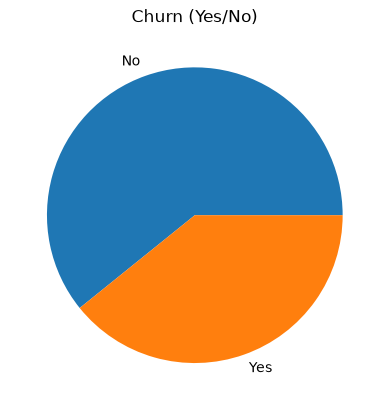

In [56]:
df['Churn'].value_counts().plot(kind='pie')
plt.title("Churn (Yes/No)")
plt.ylabel("")

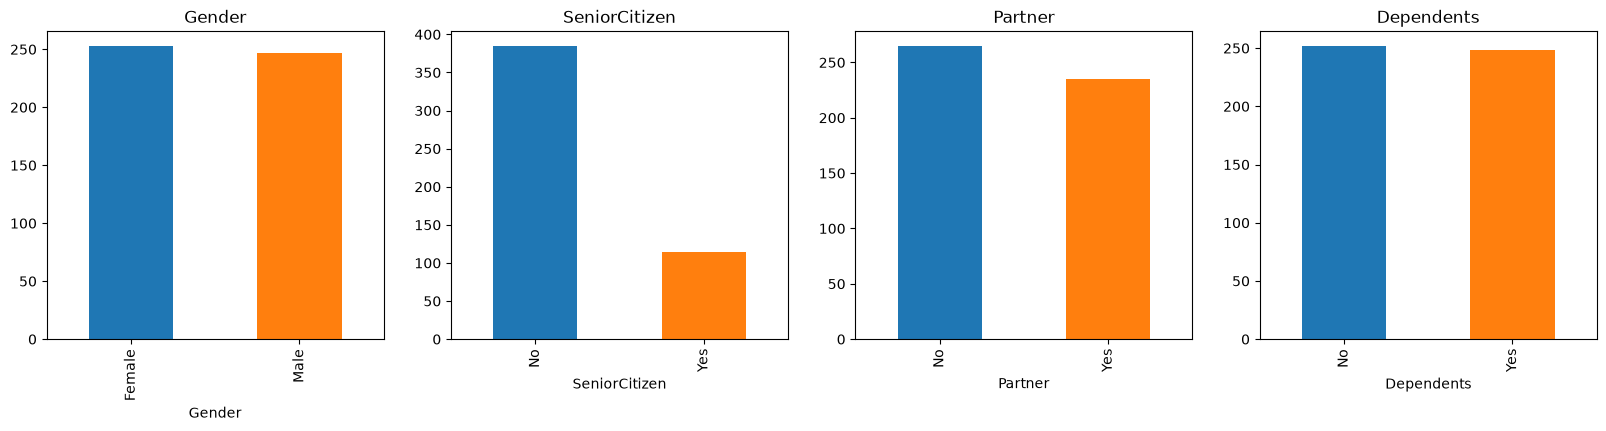

In [59]:
cols = ["Gender","SeniorCitizen","Partner","Dependents"]
numerical = cols
plt.figure(figsize=(20,4))

for i, col in enumerate(numerical):
    ax = plt.subplot(1, len(numerical), i+1)
    df[str(col)].value_counts().plot(kind='bar', color=['C0', 'C1'])
    ax.set_title(f"{col}")


In [58]:
df["Churn"].value_counts()

Churn
No     304
Yes    196
Name: count, dtype: int64

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

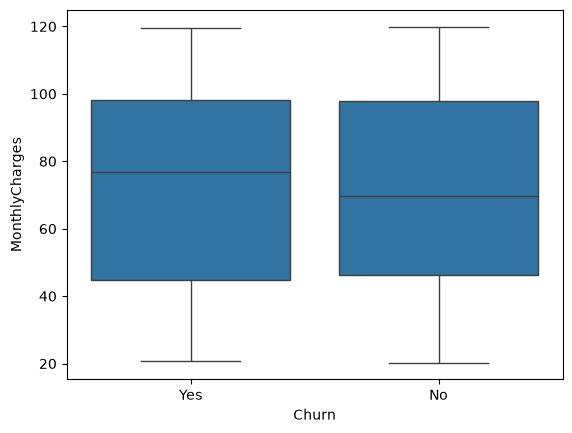

In [60]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

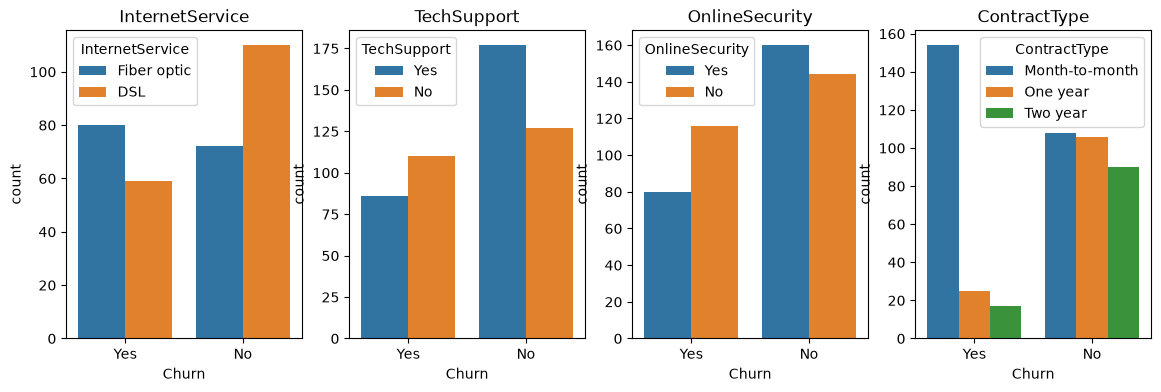

In [62]:
cols = ["InternetService","TechSupport","OnlineSecurity","ContractType"]

plt.figure(figsize=(14,4))

for i, col in enumerate(cols):
    ax = plt.subplot(1, len(cols), i+1)
    sns.countplot(x ="Churn", hue = str(col), data = df)
    ax.set_title(f"{col}")

In [63]:
def label_encode_columns(df, columns_to_encode):
    """
    Converts specified categorical variables in a DataFrame to label-encoded values.
    """
    
    label_encoders = {} 
    
    for column in columns_to_encode:
        if column in df.columns:
            le = LabelEncoder()
            df[column] = le.fit_transform(df[column])
            label_encoders[column] = le    # Save the label encoder for reversibility or reuse. 
        else:
            raise ValueError(f"Column '{column}' not found in the DataFrame.")
    
    return df

def convert_to_binary(df, columns_to_binary):
    """
    Converts variables with two classes into binary format in the given DataFrame
    """
    
    for column in columns_to_binary:
        if column in df.columns:
            unique_values = df[column].unique()
            if len(unique_values) == 2:
                # Map the two unique values to 0 and 1
                mapping = {unique_values[0]: 0, unique_values[1]: 1}
                df[column] = df[column].map(mapping)
            else:
                raise ValueError(f"Column '{column}' does not have exactly two unique values.")
        else:
            raise ValueError(f"Column '{column}' not found in the DataFrame.")
    
    return df

In [73]:
df_copy = df
df_copy = label_encode_columns(df_copy, categorical_columns)
df_copy = convert_to_binary(df_copy, convert_to_binary_columns)

df_copy

,Gender,Age,SeniorCitizen,Partner,Dependents,TenureMonths,PhoneService,InternetService,TechSupport,OnlineSecurity,StreamingTV,PaperlessBilling,ContractType,PaymentMethod,MonthlyCharges,TotalCharges,SatisfactionScore,Churn
0,0,40,0,0,0,14,0,1,1,1,0,0,0,1,11,40,9,0
1,0,28,0,0,1,35,0,1,0,0,0,1,0,0,385,365,2,0
2,1,38,0,0,0,33,0,2,1,0,1,0,1,0,383,353,8,1
3,0,5,0,0,0,29,0,0,0,1,0,1,0,3,414,335,5,0
4,1,17,0,0,1,71,1,1,1,1,0,1,0,1,103,322,6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0,31,0,0,0,59,1,1,0,1,1,1,0,3,28,193,4,0
496,0,10,0,1,0,9,0,0,1,0,0,1,0,0,315,98,2,0
497,0,28,0,0,1,6,0,0,1,1,1,1,0,1,285,56,3,0
498,1,61,1,1,0,12,0,1,1,1,0,1,2,3,375,138,8,1


In [76]:
def split_dataset(df, target_column, test_size=0.2, random_state=None):
    """
    Splits a dataset into training and test data.
    """
    # Separate features and target
    X = df.drop(columns=[target_column])
    Y = df[target_column]
    
    # Split the dataset into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, Y, test_size=test_size, random_state=random_state
    )
    
    return X_train, X_test, y_train, y_test

In [77]:
SEED = 40
X_train, X_test, y_train, y_test = split_dataset(df = df_copy, target_column='Churn', test_size=0.2, random_state=SEED)

In [78]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

c:\Users\HP\Desktop\internship\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.67      0.68        39
           1       0.79      0.82      0.81        61

    accuracy                           0.76       100
   macro avg       0.75      0.74      0.75       100
weighted avg       0.76      0.76      0.76       100



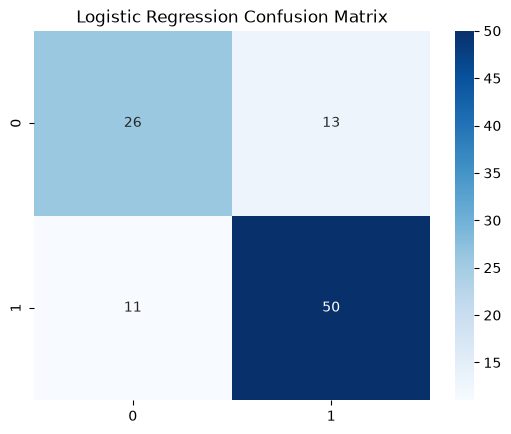

In [79]:
# predictions
y_pred_lr = lr.predict(X_test)

# classification report
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))

#confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

In [ ]:
# Decision Tree
y_pred_dt = dt.predict(X_test)
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

# Random Forest
y_pred_rf = rf.predict(X_test)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.51      0.56        39
           1       0.72      0.80      0.76        61

    accuracy                           0.69       100
   macro avg       0.67      0.66      0.66       100
weighted avg       0.68      0.69      0.68       100

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.72      0.74        39
           1       0.83      0.85      0.84        61

    accuracy                           0.80       100
   macro avg       0.79      0.79      0.79       100
weighted avg       0.80      0.80      0.80       100



ROC-AUC Score for Random Forest: 0.89
PR-AUC Score: 0.93


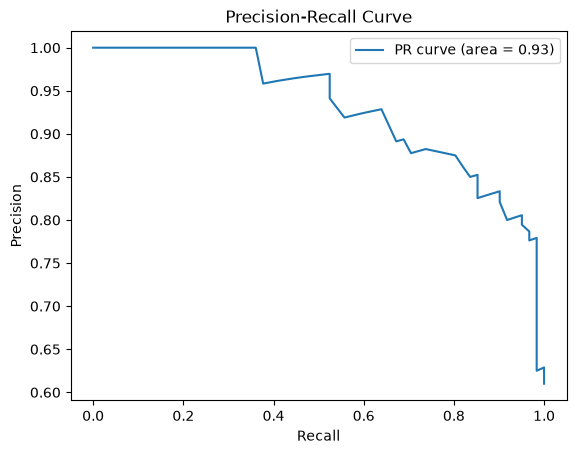

In [81]:
# evaluating model probabilities for class 1
y_pred_prob_rf = rf.predict_proba(X_test)[:,1]

# compute roc-auc
roc_auc = roc_auc_score(y_test, y_pred_prob_rf)
print(f"ROC-AUC Score for Random Forest: {roc_auc:.2f}")

from sklearn.metrics import precision_recall_curve, auc
# compute precision-recall curve and pr-auc
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob_rf)
pr_auc_rf = auc(recall, precision)
print(f"PR-AUC Score: {pr_auc_rf:.2f}")

# Plot Precision-Recall Curve
plt.figure()
plt.plot(recall, precision, label=f'PR curve (area = {pr_auc_rf:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="upper right")
plt.show()

ROC-AUC Score for Logistic Regression: 0.82
PR-AUC Score: 0.89


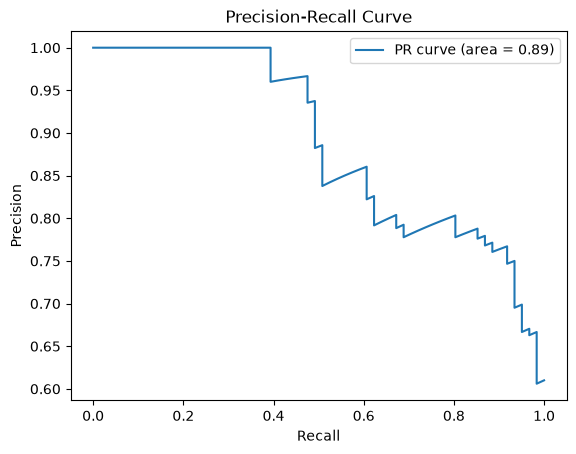

In [96]:
# evaluating model probabilities for class 1
y_pred_prob_lr = lr.predict_proba(X_test)[:,1]

# compute roc-auc
roc_auc = roc_auc_score(y_test, y_pred_prob_lr)
print(f"ROC-AUC Score for Logistic Regression: {roc_auc:.2f}")

# compute precision-recall curve and pr-auc
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob_lr)
pr_auc_lr = auc(recall, precision)
print(f"PR-AUC Score: {pr_auc_lr:.2f}")

# Plot Precision-Recall Curve
plt.figure()
plt.plot(recall, precision, label=f'PR curve (area = {pr_auc_lr:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="upper right")
plt.show()

ROC-AUC Score for Decision Tree: 0.68
PR-AUC Score: 0.83


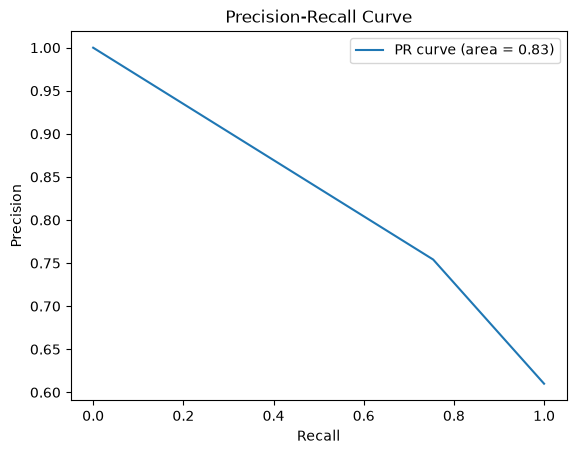

In [95]:
# evaluating model probabilities for class 1
y_pred_prob_dt = dt.predict_proba(X_test)[:,1]

# compute roc-auc
roc_auc = roc_auc_score(y_test, y_pred_prob_dt)
print(f"ROC-AUC Score for Decision Tree: {roc_auc:.2f}")

# compute precision-recall curve and pr-auc
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob_dt)
pr_auc_dt = auc(recall, precision)
print(f"PR-AUC Score: {pr_auc_dt:.2f}")

# Plot Precision-Recall Curve
plt.figure()
plt.plot(recall, precision, label=f'PR curve (area = {pr_auc_dt:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="upper right")
plt.show()

In [84]:
!pip install imblearn

  Obtaining dependency information for imblearn from https://files.pythonhosted.org/packages/81/a7/4179e6ebfd654bd0eac0b9c06125b8b4c96a9d0a8ff9e9507eb2a26d2d7e/imblearn-0.0-py2.py3-none-any.whl.metadata
  Obtaining dependency information for imbalanced-learn from https://files.pythonhosted.org/packages/91/54/760ccac7d8feeea0c191767a6b025d3ca5014084443ff48afb6fb24ef056/imbalanced_learn-0.14.2-py3-none-any.whl.metadata
  Obtaining dependency information for sklearn-compat<0.2,>=0.1.6 from https://files.pythonhosted.org/packages/b0/20/47a7e947757008be1b77f1c6a6861d26a84ef4b4ea3e6ebf4eff24f24d5d/sklearn_compat-0.1.6-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/236.1 kB ? eta -:--:--
   ---------------------------------------- 236.1/236.1 kB 7.1 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [86]:
from imblearn.over_sampling import SMOTE

# apply smote to balance dataset and return a combined df
sm = SMOTE(random_state=42, k_neighbors=5)

X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)


Text(0, 0.5, '')

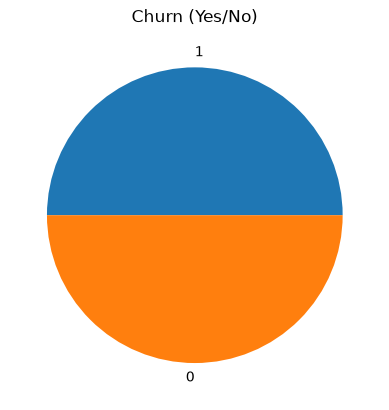

In [88]:
# do another eda to see how it impacted the size of classes
smote_df = pd.concat([X_train_sm, y_train_sm], axis=1)

smote_df['Churn'].value_counts().plot(kind='pie')
plt.title("Churn (Yes/No)")
plt.ylabel("")

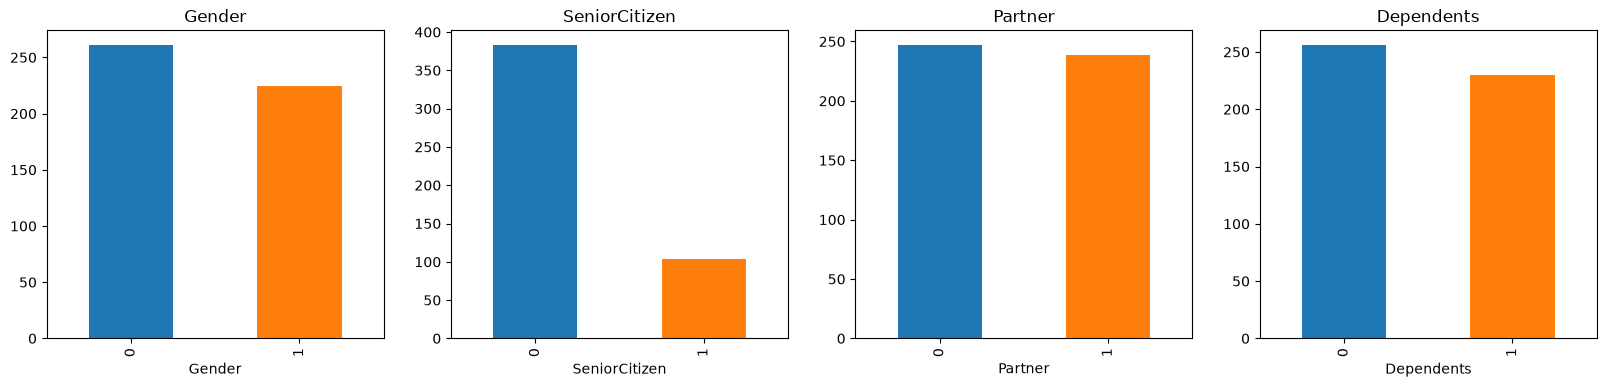

In [89]:
plt.figure(figsize=(20,4))

for i, col in enumerate(numerical):
    ax = plt.subplot(1, len(numerical), i+1)
    smote_df[str(col)].value_counts().plot(kind='bar', color=['C0', 'C1'])
    ax.set_title(f"{col}")

In [90]:
# modeling on balanced data
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_sm, y_train_sm)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sm, y_train_sm)

c:\Users\HP\Desktop\internship\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.69      0.68        39
           1       0.80      0.79      0.79        61

    accuracy                           0.75       100
   macro avg       0.74      0.74      0.74       100
weighted avg       0.75      0.75      0.75       100



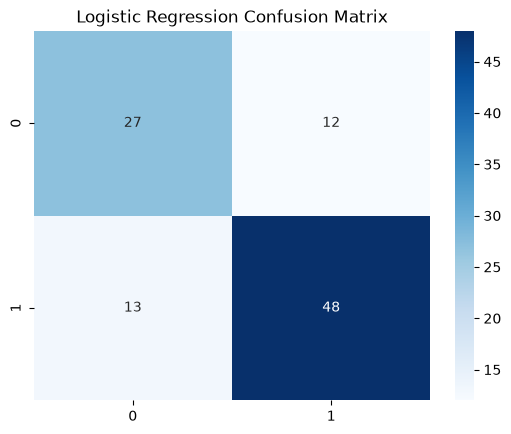

In [91]:
# predictions
y_new_pred_lr = lr.predict(X_test)

# classification report
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_new_pred_lr))

#confusion matrix
cm_lr = confusion_matrix(y_test, y_new_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

In [92]:
# Decision Tree
y_new_pred_dt = dt.predict(X_test)
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_new_pred_dt))

# Random Forest
y_new_pred_rf = rf.predict(X_test)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_new_pred_rf))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.62      0.62        39
           1       0.75      0.75      0.75        61

    accuracy                           0.70       100
   macro avg       0.68      0.68      0.68       100
weighted avg       0.70      0.70      0.70       100

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.77      0.77        39
           1       0.85      0.85      0.85        61

    accuracy                           0.82       100
   macro avg       0.81      0.81      0.81       100
weighted avg       0.82      0.82      0.82       100



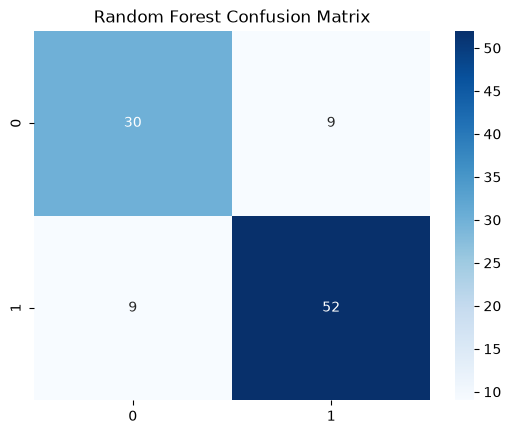

In [94]:
#confusion matrix
cm_lr = confusion_matrix(y_test, y_new_pred_rf)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.show()

ROC-AUC Score for Logistic Regression: 0.82
PR-AUC Score: 0.89


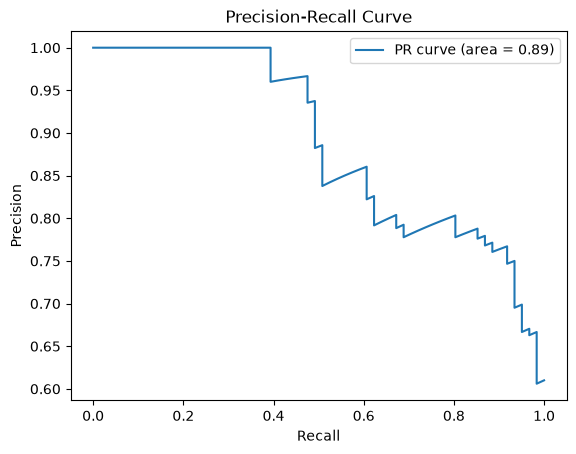

In [100]:
# evaluating model probabilities for class 1
y_pred_prob_lr = lr.predict_proba(X_test)[:,1]

# compute roc-auc
roc_auc = roc_auc_score(y_test, y_pred_prob_lr)
print(f"ROC-AUC Score for Logistic Regression: {roc_auc:.2f}")

# compute precision-recall curve and pr-auc
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob_lr)
pr_auc_lr = auc(recall, precision)
print(f"PR-AUC Score: {pr_auc_lr:.2f}")

# Plot Precision-Recall Curve
plt.figure()
plt.plot(recall, precision, label=f'PR curve (area = {pr_auc_lr:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="upper right")
plt.show()

ROC-AUC Score for Random Forest: 0.89
PR-AUC Score: 0.92


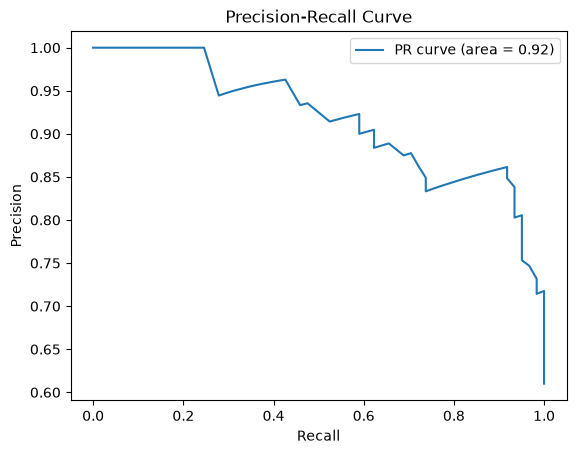

In [98]:
# evaluating model probabilities for class 1
y_pred_prob_rf = rf.predict_proba(X_test)[:,1]

# compute roc-auc
roc_auc = roc_auc_score(y_test, y_pred_prob_rf)
print(f"ROC-AUC Score for Random Forest: {roc_auc:.2f}")

# compute precision-recall curve and pr-auc
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob_rf)
pr_auc_rf = auc(recall, precision)
print(f"PR-AUC Score: {pr_auc_rf:.2f}")

# Plot Precision-Recall Curve
plt.figure()
plt.plot(recall, precision, label=f'PR curve (area = {pr_auc_rf:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="upper right")
plt.show()

ROC-AUC Score for Decision Tree: 0.68
PR-AUC Score: 0.83


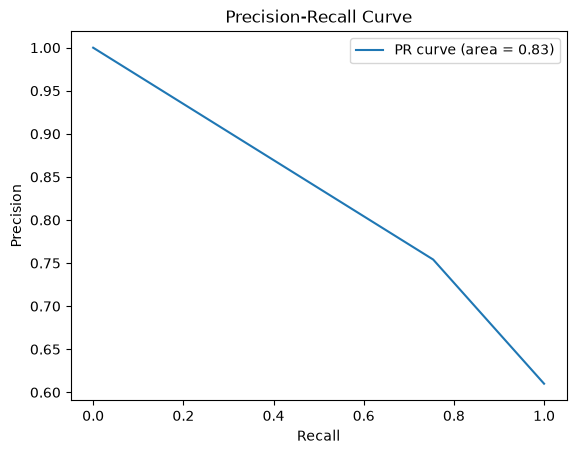

In [99]:
# evaluating model probabilities for class 1
y_pred_prob_dt = dt.predict_proba(X_test)[:,1]

# compute roc-auc
roc_auc = roc_auc_score(y_test, y_pred_prob_dt)
print(f"ROC-AUC Score for Decision Tree: {roc_auc:.2f}")

# compute precision-recall curve and pr-auc
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob_dt)
pr_auc_dt = auc(recall, precision)
print(f"PR-AUC Score: {pr_auc_dt:.2f}")

# Plot Precision-Recall Curve
plt.figure()
plt.plot(recall, precision, label=f'PR curve (area = {pr_auc_dt:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="upper right")
plt.show()